In [7]:
import requests
import pandas as pd

# 1) Endereço da API (endpoint)
url = "https://api.open-meteo.com/v1/forecast"

# 2) As 10 variáveis que queremos
variaveis = [
    "temperature_2m",             # temperatura do ar (°C)
    "apparent_temperature",       # sensação térmica (°C)
    "relative_humidity_2m",       # umidade relativa (%)
    "precipitation",              # chuva acumulada na hora (mm)
    "precipitation_probability",  # probabilidade de chuva (%)
    "cloud_cover",                # cobertura de nuvens (%)
    "wind_speed_10m",             # velocidade do vento (km/h)
    "wind_direction_10m",         # direção do vento (°)
    "pressure_msl",               # pressão ao nível do mar (hPa)
    "uv_index",                   # índice UV
]

# 3) Parâmetros da requisição: local, variáveis e fuso horário
params = {
    "latitude": -23.55,           # São Paulo
    "longitude": -46.63,
    "hourly": ",".join(variaveis),
    "timezone": "America/Sao_Paulo",
}

# 4) Chamada à API
resp = requests.get(url, params=params, timeout=10)
resp.raise_for_status()           # para o programa se a API retornar erro
dados = resp.json()               # converte a resposta JSON em dicionário Python

# 5) Transformar em DataFrame
df = pd.DataFrame(dados["hourly"])
df["time"] = pd.to_datetime(df["time"])

# 6) (Opcional) Renomear as colunas para português
df = df.rename(columns={
    "time": "data_hora",
    "temperature_2m": "temperatura",
    "apparent_temperature": "sensacao_termica",
    "relative_humidity_2m": "umidade",
    "precipitation": "chuva_mm",
    "precipitation_probability": "prob_chuva",
    "cloud_cover": "nuvens",
    "wind_speed_10m": "vento_kmh",
    "wind_direction_10m": "vento_direcao",
    "pressure_msl": "pressao",
    "uv_index": "indice_uv",
})

df.head()

,data_hora,temperatura,sensacao_termica,umidade,chuva_mm,prob_chuva,nuvens,vento_kmh,vento_direcao,pressao,indice_uv
0,2026-09-21 00:00:00,18.6,19.8,85,0.0,71,100,5.4,358,1017.1,0.0
1,2026-09-21 01:00:00,18.6,19.7,84,0.1,67,89,6.3,18,1016.1,0.0
2,2026-09-21 02:00:00,18.3,18.7,85,0.0,65,39,10.5,27,1015.1,0.0
3,2026-09-21 03:00:00,18.5,18.9,85,0.0,59,95,10.6,15,1015.1,0.0
4,2026-09-21 04:00:00,18.6,19.0,83,0.0,43,87,9.9,9,1014.7,0.0


Temperatura:
                Mímino: 13.4
                Máximo: 28.5
                Média: 18.345238095238095
                Mediana: 17.45
Sensação Térmica:
                Mímino: 12.7
                Máximo: 29.0
                Média: 18.826190476190476
                Mediana: 18.05
Umidade:
                Mímino: 37
                Máximo: 100
                Média: 81.73214285714286
                Mediana: 85.0
Chuva:
                Mímino: 0.0
                Máximo: 6.7
                Média: 0.22976190476190478
                Mediana: 0.0
-----------------------------------------------------------------------------
min: 13.4
max: 28.5
mean: 18.345238095238095
media: 17.45
min: 12.7
max: 29.0
mean: 18.826190476190476
media: 18.05
min: 37
max: 100
mean: 81.73214285714286
media: 85.0
min: 0.0
max: 6.7
mean: 0.22976190476190478
media: 0.0
-----------------------------------------------------------------------------
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
Abaixo
A

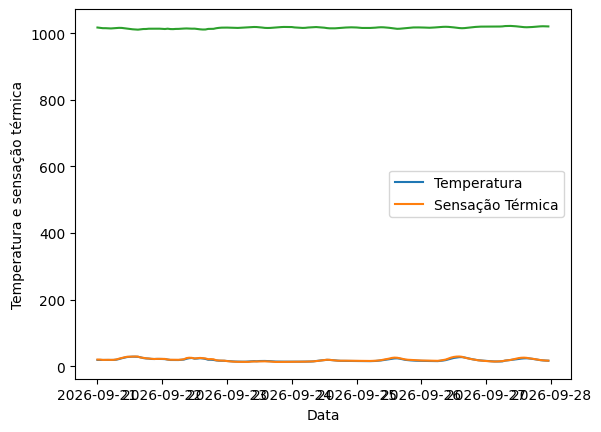

-----------------------------------------------------------------------------


In [ ]:
#Exercícios

#1. Utilizando os dados da API anterior, responda as seguinte perguntas:

#a) Quais os valores médios, medianos, min e max das colunas "temperatura", "sensacao_termica", "umidade", "chuva_mm". 

def valoresTemp():
    print(f"""Temperatura:
                Mímino: {df["temperatura"].min()}
                Máximo: {df["temperatura"].max()}
                Média: {df["temperatura"].mean()}
                Mediana: {df["temperatura"].median()}""")

def valoresSensTerm():
    print(f"""Sensação Térmica:
                Mímino: {df["sensacao_termica"].min()}
                Máximo: {df["sensacao_termica"].max()}
                Média: {df["sensacao_termica"].mean()}
                Mediana: {df["sensacao_termica"].median()}""")


def valoresUmidade():
    print(f"""Umidade:
                Mímino: {df["umidade"].min()}
                Máximo: {df["umidade"].max()}
                Média: {df["umidade"].mean()}
                Mediana: {df["umidade"].median()}""")


def valoresChuva():
    print(f"""Chuva:
                Mímino: {df["chuva_mm"].min()}
                Máximo: {df["chuva_mm"].max()}
                Média: {df["chuva_mm"].mean()}
                Mediana: {df["chuva_mm"].median()}""")

valoresTemp()
valoresSensTerm()
valoresUmidade()
valoresChuva()

print("-----------------------------------------------------------------------------")

colunas = ["temperatura", "sensacao_termica", "umidade", "chuva_mm"]

funcoes = {
    "min": lambda x: x.min(),
    "max": lambda x: x.max(),
    "mean": lambda x: x.mean(),
    "media": lambda x: x.median()
}

def lambda_temp():

    for coluna in colunas:
        for nome_funcao, funcao in funcoes.items():
            print(f"{nome_funcao}: {funcao(df[coluna])}")

lambda_temp()
print("-----------------------------------------------------------------------------")

#b) Em função da temperatura mediana, crie uma coluna que compara cada linha da coluna temperatura com a temperatura mediana e traga a informação se está abaixo, acima ou igual a mediana.

def mediana():
    filtro = df["temperatura"].median()

    for i in df["temperatura"]:
        if filtro > i:
            print("Acima")
        elif filtro == i:
            print("igual")
        elif filtro < i:
            print("Abaixo")

mediana()

print("-----------------------------------------------------------------------------")

#c) Plote a temperatura e sensacao_termica em um unico gráfico.

import matplotlib.pyplot as plt

x = df["data_hora"]
y1 = df["temperatura"]
y2 = df["sensacao_termica"]
y3 = df["pressao"]

plt.plot(x, y1, x, y2, x, y3)
plt.xlabel("Data")
plt.ylabel("Temperatura e sensação térmica")
plt.legend(["Temperatura", "Sensação Térmica"])
plt.show()

print("-----------------------------------------------------------------------------")

#d) Foi possível observar as duas colunas em um mesmo gráfico? Ou por causa de alguma coluna, o gráfico ficou achatado?

#É necessário normalizar (equação de normalização x - x(min)/ x(max) - x(min))


